# XGBoost con validacion LOSO y etiquetas individuales

Este notebook implementa el **Experimento A** con `XGBClassifier`: features derivadas de HR/R-R, ECG y variables temporales.

El objetivo es evaluar la generalizacion mediante Leave-One-Subject-Out Cross-Validation (LOSO). Las categorias `Low`, `Medium` y `High` se calculan individualmente para cada trabajador usando sus propios percentiles P33 y P66 de `FatigueIndex`.

## Definicion individual del target

Para cada trabajador se calculan sus propios P33 y P66 usando `FatigueIndex`. Esos limites generan sus etiquetas `Low`, `Medium` y `High` y se conservan durante todos los folds LOSO.

Las entradas son las columnas `_z`, ya normalizadas respecto a la baseline individual de cada trabajador. No se usa `FatigueIndex` como feature.

In [3]:
from pathlib import Path

import json
import joblib
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType as OnnxFloatTensorType

current_dir = Path.cwd()
candidate_roots = [
    current_dir,
    current_dir.parent,
    current_dir.parent.parent,
    current_dir.parent.parent.parent,
    current_dir / 'new',
]
ROOT_DIR = next(
    (
        candidate
        for candidate in candidate_roots
        if (candidate / 'W00' / 'PROCESSED' / 'combined_features_1min.csv').exists()
    ),
    current_dir,
)
DATA_DIR = ROOT_DIR
BASELINE_WINDOW_COUNT = 15
TARGET_COLUMN_CANDIDATES = ['FatigueIndex', 'fatigue_index']
LABELS = ['Low', 'Medium', 'High']
XGB_PARAM_GRID = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [3, 5, 7, 9],
    'classifier__learning_rate': [0.1, 0.2, 0.5, 0.8],
}

print(f'Directorio de datos: {DATA_DIR}')

Directorio de datos: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new


## Carga de datos

Cada CSV corresponde a un trabajador. El nombre de la carpeta (`W00`, ..., `W09`) se conserva como identificador para construir los folds. Durante la carga, cada trabajador recibe sus propios P33/P66 y su columna `FatigueLevel`; ninguna de estas columnas entra como feature del modelo.

In [4]:
def make_labels(fatigue_values, p33, p66):
    return pd.cut(
        fatigue_values,
        bins=[-np.inf, p33, p66, np.inf],
        labels=LABELS,
        right=False,
    ).astype(object)


worker_files = {
    worker_dir.name: worker_dir / 'PROCESSED' / 'combined_features_1min.csv'
    for worker_dir in sorted(DATA_DIR.glob('W[0-9][0-9]'))
    if (worker_dir / 'PROCESSED' / 'combined_features_1min.csv').exists()
}
if len(worker_files) < 2:
    raise ValueError(f'Se necesitan al menos 2 trabajadores procesados y se encontraron {len(worker_files)}: {list(worker_files)}')

data = {}
for worker, path in worker_files.items():
    frame = pd.read_csv(path)
    target_matches = [column for column in TARGET_COLUMN_CANDIDATES if column in frame.columns]
    if len(target_matches) != 1:
        raise ValueError(f'{worker}: no se encontro exactamente una columna FatigueIndex/fatigue_index')
    frame = frame.rename(columns={target_matches[0]: 'FatigueIndex'})
    frame['Trabajador'] = worker
    worker_fatigue = pd.to_numeric(frame['FatigueIndex'], errors='coerce')
    if worker_fatigue.dropna().empty:
        raise ValueError(f'{worker}: no contiene valores validos de FatigueIndex')
    worker_p33, worker_p66 = np.percentile(worker_fatigue.dropna(), [33, 66])
    frame['P33_worker'] = worker_p33
    frame['P66_worker'] = worker_p66
    frame['FatigueLevel'] = make_labels(worker_fatigue, worker_p33, worker_p66)
    data[worker] = frame

feature_columns = [
    'ECG_energy_z',
    'ECG_mean_z',
    'ECG_missing_peaks_z',
    'ECG_range_z',
    'ECG_samp_ent_z',
    'ECG_std_z',
    'HR_max_z',
    'HR_mean_z',
    'HR_min_z',
    'RMSSD_z',
    'SDNN_z',
    'pNN50_z',
    'HR_mean_ultimos_5min_z',
    'cambio_HR_vs_baseline_z',
    'tendencia_HR_z',
    'cambio_RMSSD_z',
]
missing_features = [
    column for column in feature_columns
    if column not in data[next(iter(data))].columns
]
if missing_features:
    raise ValueError(f'Faltan features requeridas: {missing_features}')
if not feature_columns:
    raise ValueError('No se encontraron columnas de entrada terminadas en _z')

print('Trabajadores:', list(data))
print('Features del Experimento A:', feature_columns)
print('Ventanas:', {worker: len(frame) for worker, frame in data.items()})
print('P33/P66 individuales:', {worker: (frame['P33_worker'].iloc[0], frame['P66_worker'].iloc[0]) for worker, frame in data.items()})

Trabajadores: ['W00', 'W01', 'W02', 'W03', 'W04', 'W05', 'W06', 'W07', 'W08', 'W09']
Features del Experimento A: ['ECG_energy_z', 'ECG_mean_z', 'ECG_missing_peaks_z', 'ECG_range_z', 'ECG_samp_ent_z', 'ECG_std_z', 'HR_max_z', 'HR_mean_z', 'HR_min_z', 'RMSSD_z', 'SDNN_z', 'pNN50_z', 'HR_mean_ultimos_5min_z', 'cambio_HR_vs_baseline_z', 'tendencia_HR_z', 'cambio_RMSSD_z']
Ventanas: {'W00': 104, 'W01': 637, 'W02': 603, 'W03': 407, 'W04': 562, 'W05': 74, 'W06': 35, 'W07': 67, 'W08': 133, 'W09': 16}
P33/P66 individuales: {'W00': (np.float64(-4.910791407727056), np.float64(-2.404562131467878)), 'W01': (np.float64(0.19857741939524748), np.float64(1.9952807675528523)), 'W02': (np.float64(0.15869861286917653), np.float64(1.8951128189329092)), 'W03': (np.float64(2.64758366326375), np.float64(6.383633710342336)), 'W04': (np.float64(-0.665956528377168), np.float64(-0.26155828390214836)), 'W05': (np.float64(-0.18718743181786043), np.float64(1.001663500738519)), 'W06': (np.float64(-2.177750214358166),

## Etiquetas y evaluacion

Las etiquetas se calculan una vez por trabajador con sus propios percentiles P33 y P66. En cada fold LOSO se dejan fuera todas las ventanas del trabajador TEST, pero sus limites individuales solo se usan para interpretar sus etiquetas; no se incorporan como features del modelo.

La matriz de confusion utiliza siempre el orden `Low`, `Medium`, `High`.

In [5]:
def make_labels(fatigue_values, p33, p66):
    return pd.cut(
        fatigue_values,
        bins=[-np.inf, p33, p66, np.inf],
        labels=LABELS,
        right=False,
    ).astype(object)


def get_worker_percentiles(worker_frame):
    worker_fatigue = pd.to_numeric(worker_frame['FatigueIndex'], errors='coerce').dropna()
    if worker_fatigue.empty:
        raise ValueError(f"{worker_frame['Trabajador'].iloc[0]} no contiene valores validos de FatigueIndex")
    return np.percentile(worker_fatigue, [33, 66])


def build_model(n_estimators=100, max_depth=3, learning_rate=0.1):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('classifier', XGBClassifier(
            objective='multi:softprob',
            num_class=len(LABELS),
            eval_metric='mlogloss',
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1,
            reg_lambda=1.0,
            tree_method='hist',
            n_jobs=1,
            random_state=42,
        )),
    ])


def encode_labels(labels):
    label_codes = pd.Categorical(labels, categories=LABELS).codes
    if (label_codes < 0).any():
        raise ValueError('Se encontro una etiqueta fuera de LABELS')
    return label_codes


def decode_labels(label_codes):
    return np.asarray(LABELS, dtype=object)[np.asarray(label_codes, dtype=int)]


def optimize_model(X_train, y_train):
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = GridSearchCV(
        estimator=build_model(),
        param_grid=XGB_PARAM_GRID,
        scoring='balanced_accuracy',
        cv=inner_cv,
        refit=True,
        n_jobs=-1,
    )
    search.fit(X_train, encode_labels(y_train))
    return search

## Experimento A

Features utilizadas: todas las columnas `_z` disponibles, que corresponden a features derivadas de HR/R-R y ECG.

La matriz de confusion utiliza siempre el orden `Low`, `Medium`, `High`.

In [6]:
fold_results = []
confusion_matrices = {}

for test_worker in sorted(data):
    train_workers = [worker for worker in sorted(data) if worker != test_worker]
    train_frame = pd.concat([data[worker] for worker in train_workers], ignore_index=True)
    test_frame = data[test_worker].copy()

    train_target = train_frame['FatigueLevel']
    test_target = test_frame['FatigueLevel']

    train_mask = train_target.notna()
    test_mask = test_target.notna()
    X_train = train_frame.loc[train_mask, feature_columns]
    y_train = train_target.loc[train_mask]
    X_test = test_frame.loc[test_mask, feature_columns]
    y_test = test_target.loc[test_mask]

    if y_train.nunique() < 2:
        raise ValueError(f'{test_worker}: TRAIN tiene menos de dos clases')
    if y_test.empty:
        raise ValueError(f'{test_worker}: TEST no contiene FatigueIndex valido')

    search = optimize_model(X_train, y_train)
    y_pred = decode_labels(search.predict(X_test))

    confusion_matrices[test_worker] = confusion_matrix(
        y_test, y_pred, labels=LABELS
    )
    matrix = confusion_matrices[test_worker]
    class_recall = np.divide(
        np.diag(matrix),
        matrix.sum(axis=1),
        out=np.zeros(len(LABELS), dtype=float),
        where=matrix.sum(axis=1) != 0,
    )
    fold_results.append({
        'Test_worker': test_worker,
        'Train_workers': ', '.join(train_workers),
        'P33_test_worker': test_frame['P33_worker'].iloc[0],
        'P66_test_worker': test_frame['P66_worker'].iloc[0],
        'N_train': len(y_train),
        'N_test': len(y_test),
        'Best_Params': str(search.best_params_),
        'Recall_Low': class_recall[0],
        'Recall_Medium': class_recall[1],
        'Recall_High': class_recall[2],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Macro_F1': f1_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0),
    })

fold_results_df = pd.DataFrame(fold_results)
mean_row = {column: np.nan for column in fold_results_df.columns}
mean_row['Test_worker'] = 'Media'
mean_row['Train_workers'] = 'Promedio de los folds'
for metric in ['P33_test_worker', 'P66_test_worker', 'N_train', 'N_test', 'Recall_Low', 'Recall_Medium', 'Recall_High', 'Accuracy', 'Balanced_Accuracy', 'Macro_F1']:
    mean_row[metric] = fold_results_df[metric].mean()
fold_results_with_mean = pd.concat(
    [fold_results_df, pd.DataFrame([mean_row])], ignore_index=True
)
fold_results_with_mean

,Test_worker,Train_workers,P33_test_worker,P66_test_worker,N_train,N_test,Best_Params,Recall_Low,Recall_Medium,Recall_High,Accuracy,Balanced_Accuracy,Macro_F1
0,W00,"W01, W02, W03, W04, W05, W06, W07, W08, W09",-4.910791,-2.404562,2534.0,104.0,"{'classifier__learning_rate': 0.2, 'classifier...",1.000000,0.000000,0.250000,0.413462,0.416667,0.317615
1,W01,"W00, W02, W03, W04, W05, W06, W07, W08, W09",0.198577,1.995281,2001.0,637.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.461905,0.752381,0.976959,0.733124,0.730415,0.719179
2,W02,"W00, W01, W03, W04, W05, W06, W07, W08, W09",0.158699,1.895113,2035.0,603.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.231156,0.849246,0.985366,0.691542,0.688589,0.644836
3,W03,"W00, W01, W02, W04, W05, W06, W07, W08, W09",2.647584,6.383634,2231.0,407.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.335821,0.000000,1.000000,0.452088,0.445274,0.367679
4,W04,"W00, W01, W02, W03, W05, W06, W07, W08, W09",-0.665957,-0.261558,2076.0,562.0,"{'classifier__learning_rate': 0.2, 'classifier...",1.000000,0.000000,0.047120,0.346975,0.349040,0.226825
5,W05,"W00, W01, W02, W03, W04, W06, W07, W08, W09",-0.187187,1.001664,2564.0,74.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.480000,0.000000,1.000000,0.500000,0.493333,0.418860
6,W06,"W00, W01, W02, W03, W04, W05, W07, W08, W09",-2.177750,0.344163,2603.0,35.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.833333,0.272727,0.583333,0.571429,0.563131,0.542768
7,W07,"W00, W01, W02, W03, W04, W05, W06, W08, W09",1.321727,2.733179,2571.0,67.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.909091,0.181818,0.739130,0.611940,0.610013,0.564260
8,W08,"W00, W01, W02, W03, W04, W05, W06, W07, W09",-0.755704,-0.078134,2505.0,133.0,"{'classifier__learning_rate': 0.2, 'classifier...",1.000000,0.545455,0.622222,0.721805,0.722559,0.714136
9,W09,"W00, W01, W02, W03, W04, W05, W06, W07, W08",0.108181,2.299379,2622.0,16.0,"{'classifier__learning_rate': 0.2, 'classifier...",1.000000,0.200000,1.000000,0.750000,0.733333,0.694444


In [7]:
print('Matrices de confusion por trabajador TEST:')
for worker, matrix in confusion_matrices.items():
    print(f'\nTEST = {worker}')
    print(pd.DataFrame(matrix, index=LABELS, columns=LABELS))

metrics = ['Accuracy', 'Balanced_Accuracy', 'Macro_F1']
summary_df = pd.DataFrame({
    'Metric': metrics,
    'Mean': [fold_results_df[metric].mean() for metric in metrics],
    'Std': [fold_results_df[metric].std(ddof=1) for metric in metrics],
})
print('Media y desviacion estandar de las metricas:')
display(summary_df)

aggregate_confusion = np.sum(
    np.stack([confusion_matrices[worker] for worker in sorted(confusion_matrices)]),
    axis=0,
)
print('Matriz de confusion agregada de los folds:')
display(pd.DataFrame(aggregate_confusion, index=LABELS, columns=LABELS))

class_support = aggregate_confusion.sum(axis=1)
predicted_support = aggregate_confusion.sum(axis=0)
class_metrics_df = pd.DataFrame({
    'Support': class_support,
    'Recall': np.divide(
        np.diag(aggregate_confusion),
        class_support,
        out=np.zeros(len(LABELS), dtype=float),
        where=class_support != 0,
    ),
    'Precision': np.divide(
        np.diag(aggregate_confusion),
        predicted_support,
        out=np.zeros(len(LABELS), dtype=float),
        where=predicted_support != 0,
    ),
}, index=LABELS)
print('Metricas agregadas por clase:')
display(class_metrics_df.round(3))

distribution_rows = []
for worker in sorted(data):
    labels = data[worker]['FatigueLevel']
    counts = labels.value_counts().reindex(LABELS, fill_value=0)
    distribution_rows.append({
        'Test_worker': worker,
        'P33_worker': data[worker]['P33_worker'].iloc[0],
        'P66_worker': data[worker]['P66_worker'].iloc[0],
        'Low': int(counts['Low']),
        'Medium': int(counts['Medium']),
        'High': int(counts['High']),
        'Total_valid': int(counts.sum()),
    })
print('Distribucion individual de clases en cada trabajador:')
display(pd.DataFrame(distribution_rows))

Matrices de confusion por trabajador TEST:

TEST = W00
        Low  Medium  High
Low      34       0     0
Medium   34       0     0
High     21       6     9

TEST = W01
        Low  Medium  High
Low      97     101    12
Medium    4     158    48
High      0       5   212

TEST = W02
        Low  Medium  High
Low      46     139    14
Medium    1     169    29
High      0       3   202

TEST = W03
        Low  Medium  High
Low      45      39    50
Medium    1       0   133
High      0       0   139

TEST = W04
        Low  Medium  High
Low     186       0     0
Medium  185       0     0
High     73     109     9

TEST = W05
        Low  Medium  High
Low      12       6     7
Medium    1       0    23
High      0       0    25

TEST = W06
        Low  Medium  High
Low      10       0     2
Medium    6       3     2
High      2       3     7

TEST = W07
        Low  Medium  High
Low      20       1     1
Medium    9       4     9
High      2       4    17

TEST = W08
        Low  Medi

,Metric,Mean,Std
0,Accuracy,0.579236,0.145595
1,Balanced_Accuracy,0.575235,0.143330
2,Macro_F1,0.521060,0.178321


Matriz de confusion agregada de los folds:


,Low,Medium,High
Low,499,286,86
Medium,260,359,249
High,100,145,654


Metricas agregadas por clase:


,Support,Recall,Precision
Low,871,0.573,0.581
Medium,868,0.414,0.454
High,899,0.727,0.661


Distribucion individual de clases en cada trabajador:


,Test_worker,P33_worker,P66_worker,Low,Medium,High,Total_valid
0,W00,-4.910791,-2.404562,34,34,36,104
1,W01,0.198577,1.995281,210,210,217,637
2,W02,0.158699,1.895113,199,199,205,603
3,W03,2.647584,6.383634,134,134,139,407
4,W04,-0.665957,-0.261558,186,185,191,562
5,W05,-0.187187,1.001664,25,24,25,74
6,W06,-2.177750,0.344163,12,11,12,35
7,W07,1.321727,2.733179,22,22,23,67
8,W08,-0.755704,-0.078134,44,44,45,133
9,W09,0.108181,2.299379,5,5,6,16


## Experimento C: ablacion ECG

Se conservan solo las features calculadas a partir del ECG. Se excluyen las features HR/R-R y las temporales, porque estas ultimas dependen de HR/R-R. `ECG_missing_peaks` se conserva como feature de calidad de picos ECG. El target sigue siendo `FatigueLevel`, creado individualmente para cada trabajador con sus propios P33 y P66.

In [8]:
# Reentrenamiento final con todos los trabajadores y optimizacion interna de XGBoost
all_frame = pd.concat([data[worker] for worker in sorted(data)], ignore_index=True)
all_fatigue = pd.to_numeric(all_frame['FatigueIndex'], errors='coerce')
all_target = all_frame['FatigueLevel']
all_mask = all_target.notna()
X_all = all_frame.loc[all_mask, feature_columns]
y_all = all_target.loc[all_mask]

final_search = optimize_model(X_all, y_all)
final_model = final_search.best_estimator_

models_dir = ROOT_DIR / 'models' / 'individual' / 'XGBOOST'
models_dir.mkdir(parents=True, exist_ok=True)
joblib_path = models_dir / 'final_xgboost_individual.joblib'
onnx_path = models_dir / 'final_xgboost_individual.onnx'
metadata_path = models_dir / 'final_xgboost_individual_metadata.json'

joblib.dump(final_model, joblib_path)
onnx_model = convert_xgboost(
    final_model.named_steps['classifier'],
    initial_types=[('features', OnnxFloatTensorType([None, len(feature_columns)]))],
    target_opset=15,
)
onnx_path.write_bytes(onnx_model.SerializeToString())

metadata = {
    'model_type': 'XGBClassifier',
    'validation': 'LOSO_with_individual_worker_labels_and_inner_XGBoost_search',
    'training_workers': sorted(data),
    'feature_columns': feature_columns,
    'feature_count': len(feature_columns),
    'labels': LABELS,
    'preprocessing': 'SimpleImputer(strategy=median), applied before ONNX inference',
    'xgb_param_grid': XGB_PARAM_GRID,
    'selected_params_final': {
        key.replace('classifier__', ''): value
        for key, value in final_search.best_params_.items()
    },
    'target_definition': 'P33/P66 calculados individualmente para cada trabajador',
    'target_column': 'FatigueLevel derived from FatigueIndex',
    'worker_percentiles': {
        worker: {
            'p33': float(data[worker]['P33_worker'].iloc[0]),
            'p66': float(data[worker]['P66_worker'].iloc[0]),
        }
        for worker in sorted(data)
    },
    'temporal_features': [
        'HR_mean_ultimos_5min_z',
        'cambio_HR_vs_baseline_z',
        'tendencia_HR_z',
        'cambio_RMSSD_z',
    ],
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')

print(f'Modelo final entrenado con {len(y_all)} ventanas y {len(feature_columns)} features')
print(f'Parametros finales seleccionados: {final_search.best_params_}')
print(f'Modelo joblib guardado en: {joblib_path}')
print(f'Modelo ONNX guardado en: {onnx_path}')
print(f'Metadatos guardados en: {metadata_path}')

Modelo final entrenado con 2638 ventanas y 16 features
Parametros finales seleccionados: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 7, 'classifier__n_estimators': 200}
Modelo joblib guardado en: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\models\individual\XGBOOST\final_xgboost_individual.joblib
Modelo ONNX guardado en: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\models\individual\XGBOOST\final_xgboost_individual.onnx
Metadatos guardados en: c:\Users\Carlo\Desktop\owncloud 2025-08-11 ECG\new\models\individual\XGBOOST\final_xgboost_individual_metadata.json


## Experimento B: ablacion HR/R-R

Se conservan solo las features calculadas a partir de HR/R-R y las cuatro features temporales. Se eliminan las features ECG. El target sigue siendo `FatigueLevel`, creado individualmente para cada trabajador con sus propios P33 y P66.

In [9]:
HR_RR_FEATURES = [
    'SDNN_z',
    'RMSSD_z',
    'pNN50_z',
    'HR_mean_z',
    'HR_max_z',
    'HR_min_z',
    'HR_mean_ultimos_5min_z',
    'cambio_HR_vs_baseline_z',
    'tendencia_HR_z',
    'cambio_RMSSD_z',
]

ECG_FEATURES = [
    'ECG_energy_z',
    'ECG_mean_z',
    'ECG_missing_peaks_z',
    'ECG_range_z',
    'ECG_samp_ent_z',
    'ECG_std_z',
]


def run_ablation_experiment(experiment_name, selected_features):
    results = []
    for test_worker in sorted(data):
        train_workers = [worker for worker in sorted(data) if worker != test_worker]
        train_frame = pd.concat([data[worker] for worker in train_workers], ignore_index=True)
        test_frame = data[test_worker].copy()
        train_target = train_frame['FatigueLevel']
        test_target = test_frame['FatigueLevel']
        train_mask = train_target.notna()
        test_mask = test_target.notna()
        X_train = train_frame.loc[train_mask, selected_features]
        y_train = train_target.loc[train_mask]
        X_test = test_frame.loc[test_mask, selected_features]
        y_test = test_target.loc[test_mask]
        search = optimize_model(X_train, y_train)
        y_pred = decode_labels(search.predict(X_test))
        results.append({
            'Experiment': experiment_name,
            'Test_worker': test_worker,
            'P33_test_worker': test_frame['P33_worker'].iloc[0],
            'P66_test_worker': test_frame['P66_worker'].iloc[0],
            'N_train': len(y_train),
            'N_test': len(y_test),
            'Feature_count': len(selected_features),
            'Best_Params': str(search.best_params_),
            'Accuracy': accuracy_score(y_test, y_pred),
            'Balanced_Accuracy': balanced_accuracy_score(y_test, y_pred),
            'Macro_F1': f1_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0),
        })
    return pd.DataFrame(results)


def add_mean_row(results_frame):
    mean_row = {column: np.nan for column in results_frame.columns}
    mean_row['Test_worker'] = 'Media'
    numeric_columns = results_frame.select_dtypes(include='number').columns
    for column in numeric_columns:
        mean_row[column] = results_frame[column].mean()
    return pd.concat([results_frame, pd.DataFrame([mean_row])], ignore_index=True)


hr_rr_results = run_ablation_experiment('Solo HR/RR + temporales', HR_RR_FEATURES)
hr_rr_results_with_mean = add_mean_row(hr_rr_results)
print('Resultados del Experimento B por trabajador y promedio:')
display(hr_rr_results_with_mean.round(4))

Resultados del Experimento B por trabajador y promedio:


,Experiment,Test_worker,P33_test_worker,P66_test_worker,N_train,N_test,Feature_count,Best_Params,Accuracy,Balanced_Accuracy,Macro_F1
0,Solo HR/RR + temporales,W00,-4.9108,-2.4046,2534.0,104.0,10.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.4135,0.4167,0.3132
1,Solo HR/RR + temporales,W01,0.1986,1.9953,2001.0,637.0,10.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.4757,0.4765,0.4160
2,Solo HR/RR + temporales,W02,0.1587,1.8951,2035.0,603.0,10.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.4677,0.4694,0.4139
3,Solo HR/RR + temporales,W03,2.6476,6.3836,2231.0,407.0,10.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.5061,0.5001,0.4392
4,Solo HR/RR + temporales,W04,-0.6660,-0.2616,2076.0,562.0,10.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.3790,0.3829,0.2737
5,Solo HR/RR + temporales,W05,-0.1872,1.0017,2564.0,74.0,10.0,"{'classifier__learning_rate': 0.5, 'classifier...",0.4324,0.4339,0.4352
6,Solo HR/RR + temporales,W06,-2.1778,0.3442,2603.0,35.0,10.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.6286,0.6111,0.4962
7,Solo HR/RR + temporales,W07,1.3217,2.7332,2571.0,67.0,10.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.5821,0.5784,0.5472
8,Solo HR/RR + temporales,W08,-0.7557,-0.0781,2505.0,133.0,10.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.3459,0.3481,0.2399
9,Solo HR/RR + temporales,W09,0.1082,2.2994,2622.0,16.0,10.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.5625,0.5667,0.5835


## Modelo final y exportacion

La evaluacion LOSO mide la generalizacion dejando un trabajador fuera en cada fold. Despues, el modelo final se reentrena con todos los trabajadores usando sus etiquetas individuales. El pipeline se guarda en `joblib`, ONNX y JSON con los percentiles individuales utilizados.

In [10]:
ecg_results = run_ablation_experiment('Solo ECG', ECG_FEATURES)
ecg_results_with_mean = add_mean_row(ecg_results)
print('Resultados del Experimento C por trabajador y promedio:')
display(ecg_results_with_mean.round(4))

ec_results = pd.concat([hr_rr_results, ecg_results], ignore_index=True)
ablation_summary = (
    ec_results.groupby('Experiment')[['Accuracy', 'Balanced_Accuracy', 'Macro_F1']]
    .agg(['mean', 'std'])
    .round(4)
)
print('Resumen de las ablaciones:')
display(ablation_summary)

xgboost_summary = pd.DataFrame({
    'Experiment': [
        'A: ECG + HR/RR + temporales',
        'B: HR/RR + temporales',
        'C: ECG',
    ],
    'Feature_count': [
        len(feature_columns),
        len(HR_RR_FEATURES),
        len(ECG_FEATURES),
    ],
    'Accuracy_mean': [
        fold_results_df['Accuracy'].mean(),
        hr_rr_results['Accuracy'].mean(),
        ecg_results['Accuracy'].mean(),
    ],
    'Balanced_Accuracy_mean': [
        fold_results_df['Balanced_Accuracy'].mean(),
        hr_rr_results['Balanced_Accuracy'].mean(),
        ecg_results['Balanced_Accuracy'].mean(),
    ],
    'Macro_F1_mean': [
        fold_results_df['Macro_F1'].mean(),
        hr_rr_results['Macro_F1'].mean(),
        ecg_results['Macro_F1'].mean(),
    ],
})
print('Resumen comparativo de los experimentos XGBoost:')
display(xgboost_summary.round(4))

Resultados del Experimento C por trabajador y promedio:


,Experiment,Test_worker,P33_test_worker,P66_test_worker,N_train,N_test,Feature_count,Best_Params,Accuracy,Balanced_Accuracy,Macro_F1
0,Solo ECG,W00,-4.9108,-2.4046,2534.0,104.0,6.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.4231,0.4259,0.3804
1,Solo ECG,W01,0.1986,1.9953,2001.0,637.0,6.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.7834,0.7816,0.7809
2,Solo ECG,W02,0.1587,1.8951,2035.0,603.0,6.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.6849,0.6844,0.6848
3,Solo ECG,W03,2.6476,6.3836,2231.0,407.0,6.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.4619,0.4555,0.3714
4,Solo ECG,W04,-0.6660,-0.2616,2076.0,562.0,6.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.3292,0.3314,0.1961
5,Solo ECG,W05,-0.1872,1.0017,2564.0,74.0,6.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.4324,0.4272,0.3638
6,Solo ECG,W06,-2.1778,0.3442,2603.0,35.0,6.0,"{'classifier__learning_rate': 0.1, 'classifier...",0.3714,0.3687,0.3696
7,Solo ECG,W07,1.3217,2.7332,2571.0,67.0,6.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.4179,0.4203,0.4086
8,Solo ECG,W08,-0.7557,-0.0781,2505.0,133.0,6.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.6617,0.6618,0.6637
9,Solo ECG,W09,0.1082,2.2994,2622.0,16.0,6.0,"{'classifier__learning_rate': 0.2, 'classifier...",0.7500,0.7333,0.7368


Resumen de las ablaciones:


Accuracy         Balanced_Accuracy         Macro_F1  \
                            mean     std              mean     std     mean   
Experiment                                                                    
Solo ECG                  0.5316  0.1692            0.5290  0.1668   0.4956   
Solo HR/RR + temporales   0.4793  0.0913            0.4784  0.0868   0.4158   

                                 
                            std  
Experiment                       
Solo ECG                 0.2008  
Solo HR/RR + temporales  0.1128

Resumen comparativo de los experimentos XGBoost:


,Experiment,Feature_count,Accuracy_mean,Balanced_Accuracy_mean,Macro_F1_mean
0,A: ECG + HR/RR + temporales,16,0.5792,0.5752,0.5211
1,B: HR/RR + temporales,10,0.4793,0.4784,0.4158
2,C: ECG,6,0.5316,0.5290,0.4956


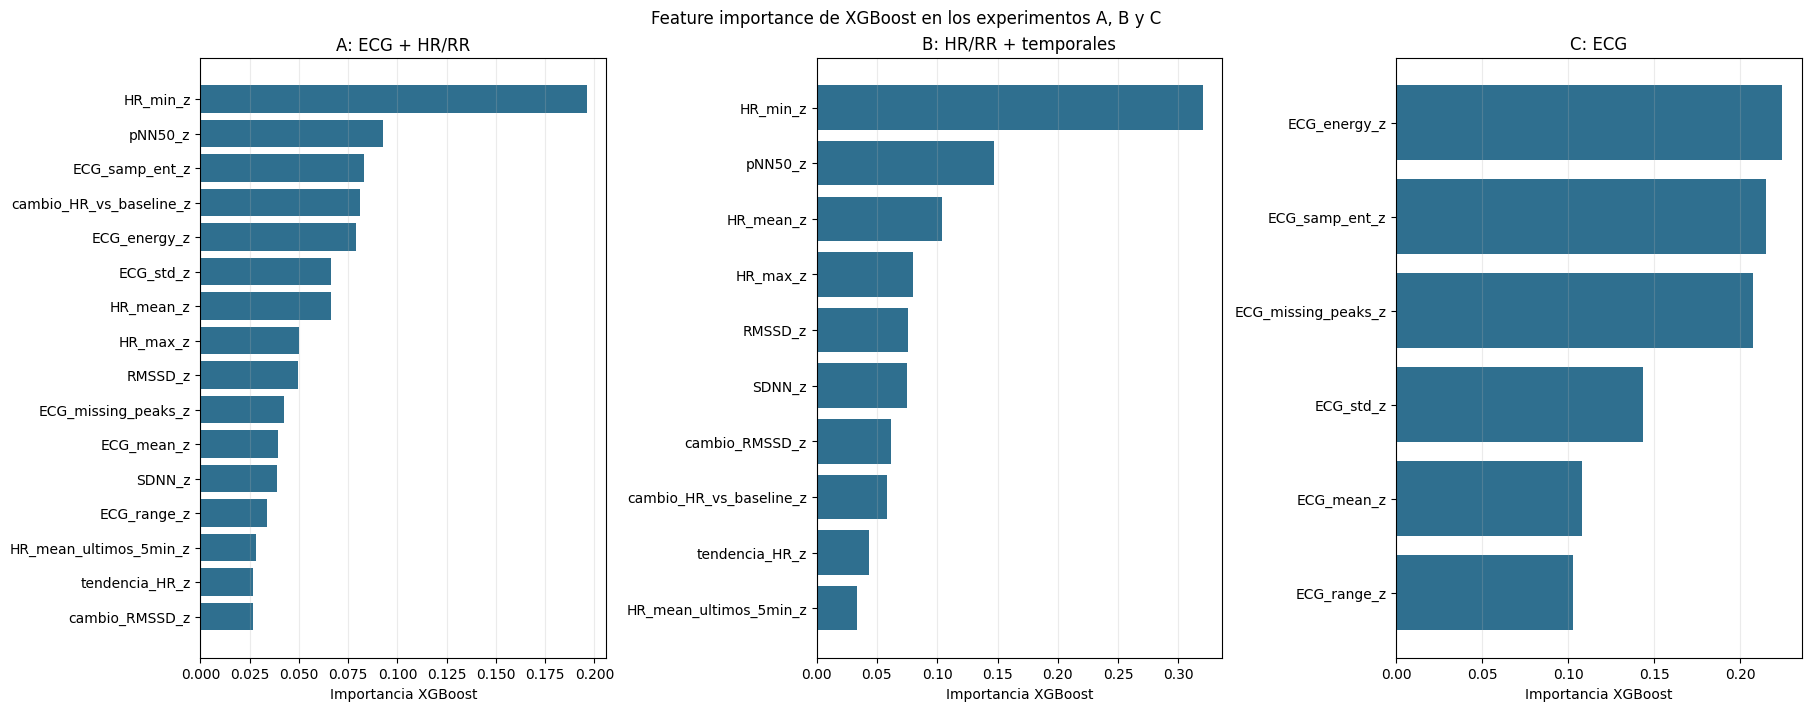

Features ordenadas por importancia:

A: ECG + HR/RR


,Feature,Importance
8,HR_min_z,0.1961
11,pNN50_z,0.0928
4,ECG_samp_ent_z,0.0832
13,cambio_HR_vs_baseline_z,0.0810
0,ECG_energy_z,0.0787
5,ECG_std_z,0.0661
7,HR_mean_z,0.0661
6,HR_max_z,0.0498
9,RMSSD_z,0.0497
2,ECG_missing_peaks_z,0.0424



B: HR/RR + temporales


,Feature,Importance
5,HR_min_z,0.3204
2,pNN50_z,0.1468
3,HR_mean_z,0.1043
4,HR_max_z,0.0798
1,RMSSD_z,0.0759
0,SDNN_z,0.0751
9,cambio_RMSSD_z,0.0620
7,cambio_HR_vs_baseline_z,0.0583
8,tendencia_HR_z,0.0436
6,HR_mean_ultimos_5min_z,0.0339



C: ECG


,Feature,Importance
0,ECG_energy_z,0.2243
4,ECG_samp_ent_z,0.2148
2,ECG_missing_peaks_z,0.2071
5,ECG_std_z,0.1433
1,ECG_mean_z,0.1077
3,ECG_range_z,0.1028


In [11]:
import matplotlib.pyplot as plt


def fit_final_feature_model(selected_features):
    X_selected = all_frame.loc[all_mask, selected_features]
    return optimize_model(X_selected, y_all).best_estimator_


models_by_experiment = {
    'A: ECG + HR/RR': (feature_columns, fit_final_feature_model(feature_columns)),
    'B: HR/RR + temporales': (HR_RR_FEATURES, fit_final_feature_model(HR_RR_FEATURES)),
    'C: ECG': (ECG_FEATURES, fit_final_feature_model(ECG_FEATURES)),
}

importance_tables = {}
for experiment_name, (selected_features, model) in models_by_experiment.items():
    importance = model.named_steps['classifier'].feature_importances_
    importance_tables[experiment_name] = (
        pd.DataFrame({'Feature': selected_features, 'Importance': importance})
        .sort_values('Importance', ascending=True)
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 7), constrained_layout=True)
for axis, (experiment_name, importance_table) in zip(axes, importance_tables.items()):
    axis.barh(importance_table['Feature'], importance_table['Importance'], color='#2f6f8f')
    axis.set_title(experiment_name)
    axis.set_xlabel('Importancia XGBoost')
    axis.grid(axis='x', alpha=0.25)

fig.suptitle('Feature importance de XGBoost en los experimentos A, B y C')
plt.show()

print('Features ordenadas por importancia:')
for experiment_name, importance_table in importance_tables.items():
    print(f'\n{experiment_name}')
    display(importance_table.sort_values('Importance', ascending=False).round(4))